In [ ]:
1. Introduction

In [ ]:
The Problem

The video game industry is highly competitive, and not every released game becomes commercially successful. Some games become major “hits” with high global sales, while others fail to reach a wide audience.

The goal of this project is to build a predictive model that classifies Nintendo games as either:

Hit games (1): games with high commercial success
Non-hit games (0): games with lower sales performance

Using features such as genre, platform, publisher, and release year, we aim to predict whether a game will be successful before or shortly after release.

This is a binary classification problem in supervised machine learning.

In [ ]:
The Data

The dataset contains information about Nintendo games, including:

Title
Platform
Genre
Publisher
Release date
Meta score (critical rating)
ESRB rating
Developers

In [ ]:
Defining the Target Variable

Target definition:

Hit = meta_score ≥ median(meta_score)
Non-Hit = meta_score < median(meta_score)

median_score = df['meta_score'].median()
df['Hit'] = (df['meta_score'] >= median_score).astype(int)

In [ ]:
Questions of Interest

What features influence whether a game receives a high meta score?
Do certain genres consistently receive higher ratings?
Does platform (Switch vs Wii vs DS) affect critic reception?
Are certain developers or publishers associated with higher-rated games?
Can we predict whether a game will be critically successful?

In [ ]:
2. Import Libraries and Data

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score

In [ ]:
3. Loading the Preprocessed Dataset and Feature Selection

In [ ]:
import pandas as pd

df = pd.read_csv("nintendo_games_processed.csv")

df['Hit'] = (
    df['meta_score'] >= df['meta_score'].median()
).astype(int)

X = df.drop(['Hit', 'meta_score'], axis=1)
y = df['Hit']
print(X.shape)
print(y.shape)

(1094, 44)
(1094,)


In [ ]:
df.head()

,user_score,platform_DS,platform_GBA,platform_GC,platform_N64,platform_Switch,platform_TG16),platform_WII,platform_WIIU,platform_iOS,...,"genres_['Miscellaneous', 'Party / Minigame']","genres_['Miscellaneous', 'Puzzle', 'Puzzle', 'General', 'Puzzle', 'General']","genres_['Role-Playing', 'Action RPG']","genres_['Role-Playing', 'Console-style RPG']","genres_['Role-Playing', 'Japanese-Style']","genres_['Role-Playing', 'Trainer']","genres_['Strategy', 'Turn-Based', 'Fantasy', 'Fantasy', 'Tactics']","genres_['Strategy', 'Turn-Based', 'Tactics']",meta_score,Hit
0,7.9,False,False,False,False,True,False,False,False,False,...,False,False,False,False,True,False,False,False,77.0,1
1,7.9,False,False,False,False,True,False,False,False,False,...,True,False,False,False,False,False,False,False,77.0,1
2,7.9,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,77.0,1
3,7.9,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,77.0,1
4,7.9,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,77.0,1


In [ ]:
The data preprocessing steps were completed in the previous notebook. These steps included handling missing values, encoding 
categorical variables, and preparing the final modeling dataset.

To avoid duplicating preprocessing work, this notebook loads the processed dataset and focuses on model training, evaluation, and 
comparison.

In [ ]:
4. Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [ ]:
5. Modeling

In [ ]:
5.1 Logistic Regression (Baseline)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

logreg = LogisticRegression(max_iter=1000)

logreg.fit(X_train, y_train)

y_pred_lr = logreg.predict(X_test)

accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", accuracy_lr)

Logistic Regression Accuracy: 0.7294685990338164


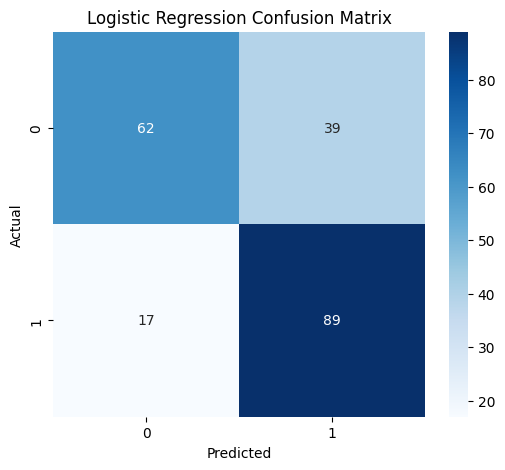

In [ ]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')

plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [ ]:
5.2 Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

tree_gini = DecisionTreeClassifier(
    criterion='gini',
    random_state=42
)

tree_entropy = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42
)

tree_gini.fit(X_train, y_train)
tree_entropy.fit(X_train, y_train)

y_pred_gini = tree_gini.predict(X_test)
y_pred_entropy = tree_entropy.predict(X_test)

accuracy_gini = accuracy_score(y_test, y_pred_gini)
accuracy_entropy = accuracy_score(y_test, y_pred_entropy)

print("Decision Tree (Gini) Accuracy:", accuracy_gini)
print("Decision Tree (Entropy) Accuracy:", accuracy_entropy)

Decision Tree (Gini) Accuracy: 0.6956521739130435
Decision Tree (Entropy) Accuracy: 0.6570048309178744


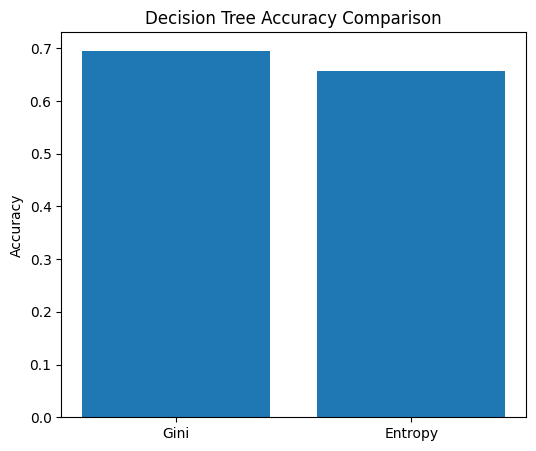

In [ ]:
models = ['Gini', 'Entropy']
scores = [accuracy_gini, accuracy_entropy]

plt.figure(figsize=(6,5))

plt.bar(models, scores)

plt.title('Decision Tree Accuracy Comparison')
plt.ylabel('Accuracy')

plt.show()

In [ ]:
5.3 Random Forest Model

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)

Random Forest Accuracy: 0.7439613526570048


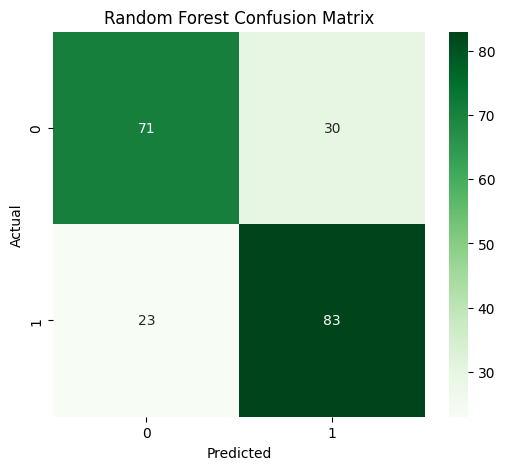

In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')

plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [ ]:
6. Cross-Validation Comparison

In [ ]:
models = {
    "Logistic Regression": logreg,
    "Decision Tree": tree_gini,
    "Random Forest": rf
}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    print(name)
    print("CV Accuracy:", scores.mean())
    print()

Logistic Regression
CV Accuracy: 0.7288015463917525

Decision Tree
CV Accuracy: 0.6501288659793814

Random Forest
CV Accuracy: 0.7496134020618557



In [ ]:
7. Model Comparison Table

In [ ]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree (Gini)", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_gini),
        accuracy_score(y_test, y_pred_rf)
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.729469
1,Decision Tree (Gini),0.695652
2,Random Forest,0.743961


In [ ]:
8. Feature Importance (Random Forest)

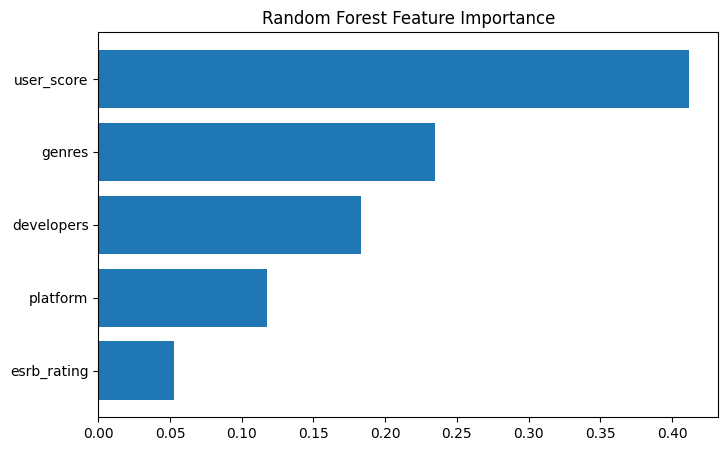

In [ ]:
importances = rf.feature_importances_

feat_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
})

feat_importance = feat_importance.sort_values(
    by='Importance',
    ascending=True
)

plt.figure(figsize=(8,5))

plt.barh(
    feat_importance['Feature'],
    feat_importance['Importance']
)

plt.title('Random Forest Feature Importance')

plt.show()

In [ ]:
9. ROC Curve

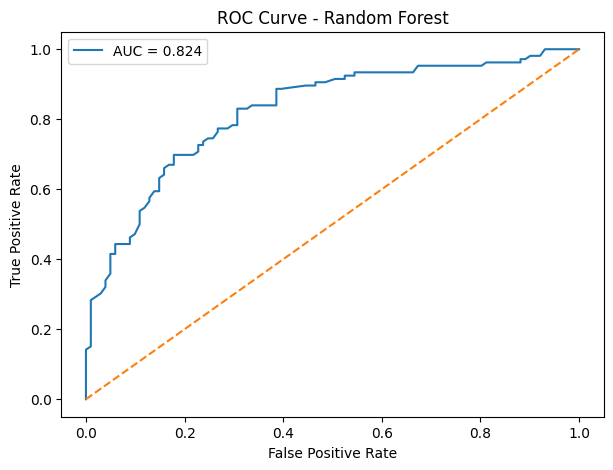

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob_rf = rf.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)

roc_auc = roc_auc_score(y_test, y_prob_rf)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC Curve - Random Forest')

plt.legend()

plt.show()

In [ ]:
10. Conclusion 

In [ ]:
After comparing the performance of the classification models, the Random Forest classifier achieved the strongest overall performance 
in terms of both testing accuracy and cross-validation accuracy.

The Random Forest model also demonstrated strong generalization performance and produced the clearest feature importance analysis.
The most influential features in predicting whether a Nintendo game would be considered a “Hit” were user score, genre, and ESRB rating.

Although Logistic Regression provided a strong baseline model, the ensemble-based Random Forest model captured nonlinear relationships
more effectively and produced higher predictive performance.

Therefore, Random Forest was selected as the final model for this project.

In [ ]:
11. Next Steps

In [ ]:
Although the machine learning models produced strong classification results, there are several ways the project could be improved in future work.

First, additional features could significantly improve prediction accuracy. The current dataset mainly contains metadata and review-related information. 
Including variables such as sales data, critic review counts, multiplayer support, franchise information, or release season could 
provide more predictive power.

Second, more advanced machine learning algorithms could be explored. In this project, Logistic Regression, Decision Tree, 
and Random Forest classifiers were used. Future versions of the project could implement ensemble boosting methods such as XGBoost 
or LightGBM, which often outperform traditional tree-based models on structured datasets.

Another improvement would involve more sophisticated feature engineering. For example:

extracting release year from the full date column,
grouping ESRB ratings into broader categories,
analyzing developer reputation based on historical average scores,
or creating platform generation groupings.

The project could also benefit from hyperparameter tuning using GridSearchCV or RandomizedSearchCV to further optimize model 
performance.

Additionally, the current project simplified the target variable into a binary “Hit” vs “Non-Hit” classification problem. 
Future work could instead approach this as:
a multiclass classification problem (low, medium, high rated games),
or a regression problem predicting the exact meta score value.

Finally, a larger dataset including games from other publishers and gaming platforms beyond Nintendo could improve generalization and 
allow broader industry-level analysis.